# Mini Project-4 (EDA-2): Netflix Movies and TV Shows

**EDA Project**

1. Dataset Understanding  
2. Data Cleaning  
3. Content Type Analysis  
4. Country Analysis  
5. Yearly Trend Analysis  
6. Rating Analysis  
7. Genre Analysis  
8. Duration Analysis  
9. Outlier Analysis  
10. Feature Engineering  
11. Multivariate Analysis  
12. Business Insights and Recommendations

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    display = print
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
PLOT_DIR = Path("mini4_plots")
PLOT_DIR.mkdir(exist_ok=True)
def save_plot(file_name):
    """Save and show the current matplotlib plot."""
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{file_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
possible_paths = [    "NetFlix.csv"
]
DATA_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break
if DATA_PATH is None:
    raise FileNotFoundError("CSV file not found. Put NetFlix(2).csv in the same folder as this notebook.")
print("Using dataset:", DATA_PATH)
df = pd.read_csv(DATA_PATH)

Using dataset: NetFlix.csv


## Task 1: Dataset Understanding

In [2]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
display(df.head())
print("\nDataset Info:")
df.info()
print("\nStatistical Summary:")
display(df.describe(include="all"))
print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

Dataset Shape: (7787, 12)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'genres', 'description']

First 5 Rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, Rodolfo Valente, Vaneza Oliveira, Rafael Lozano, Vi...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi & Fantasy","In a future where the elite inhabit an island paradise far from the crowded slums, you get one c..."
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengupta, Anjori Alagh, Rajendranath Zutshi, Vipin Sharm...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle that is slated to become a luxury hotel. But someth...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro, Chelsea Islan",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becoming the first of their nation to medal in archery a...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob Ramsay, Chris Romano, Frankie Shaw, Omari Newton, E...",United States,1-Mar-16,2016,R,90,Comedies,"New NFL star Thad buys his old teammates' beloved frat house, renames it Thadland and throws the..."
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV","This sequel to the award-winning nature series ""Blue Planet"" dives beneath Earth's oceans to rev..."



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   int64
 10  genres        7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(2), str(10)
memory usage: 730.2 KB

Statistical Summary:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787.000000,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,NaN,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,NaN,TV-MA,NaN,Documentaries,Multiple women report their husbands as missing but when it appears they are looking for the sam...
freq,1,5377,1,18,18,2555,118,NaN,2863,NaN,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,69.122769,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,50.950743,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,88.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,106.000000,NaN,NaN



Missing Values:


,Missing Values
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


## Task 2: Data Cleaning

Cleaning steps used:
- Remove duplicate records.
- Fill missing `director`, `cast`, and `country` values with **Unknown**.
- Fill missing `rating` values with the most common rating.
- Convert `date_added` into datetime format.
- Create a clean numeric duration column named `duration_num`.

In [3]:
netflix = df.copy()
print("Duplicate Rows Before Cleaning:", netflix.duplicated().sum())
netflix.drop_duplicates(inplace=True)
for col in ["director", "cast", "country"]:
    if col in netflix.columns:
        netflix[col] = netflix[col].fillna("Unknown")
if netflix["rating"].isnull().sum() > 0:
    netflix["rating"] = netflix["rating"].fillna(netflix["rating"].mode()[0])
netflix["date_added"] = netflix["date_added"].astype(str).str.strip()
netflix["date_added"] = pd.to_datetime(netflix["date_added"], format="%d-%b-%y", errors="coerce")
netflix["duration_num"] = pd.to_numeric(netflix["duration"], errors="coerce")
if netflix["duration_num"].isna().sum() > 0:
    extracted_duration = netflix["duration"].astype(str).str.extract(r"(\d+)")[0]
    netflix["duration_num"] = pd.to_numeric(extracted_duration, errors="coerce")
print("Duplicate Rows After Cleaning:", netflix.duplicated().sum())
print("\nMissing Values After Cleaning:")
display(netflix.isnull().sum().to_frame("Missing Values"))
print("\nCleaned Dataset Preview:")
display(netflix.head())

Duplicate Rows Before Cleaning: 0
Duplicate Rows After Cleaning: 0

Missing Values After Cleaning:


,Missing Values
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0



Cleaned Dataset Preview:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,duration_num
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, Rodolfo Valente, Vaneza Oliveira, Rafael Lozano, Vi...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi & Fantasy","In a future where the elite inhabit an island paradise far from the crowded slums, you get one c...",4
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengupta, Anjori Alagh, Rajendranath Zutshi, Vipin Sharm...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle that is slated to become a luxury hotel. But someth...,143
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro, Chelsea Islan",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becoming the first of their nation to medal in archery a...,124
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob Ramsay, Chris Romano, Frankie Shaw, Omari Newton, E...",United States,2016-03-01,2016,R,90,Comedies,"New NFL star Thad buys his old teammates' beloved frat house, renames it Thadland and throws the...",90
4,s1001,TV Show,Blue Planet II,Unknown,David Attenborough,United Kingdom,2018-12-03,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV","This sequel to the award-winning nature series ""Blue Planet"" dives beneath Earth's oceans to rev...",1


## Task 3: Content Type Analysis

Questions:
1. How many Movies?
2. How many TV Shows?
3. Percentage distribution.

Visualizations:
- Count Plot
- Pie Chart

In [4]:
type_counts = netflix["type"].value_counts()
type_percentage = (netflix["type"].value_counts(normalize=True) * 100).round(2)
content_type_summary = pd.DataFrame({
    "Count": type_counts,
    "Percentage (%)": type_percentage
})
display(content_type_summary)
print(f"Movies: {type_counts.get('Movie', 0)}")
print(f"TV Shows: {type_counts.get('TV Show', 0)}")

,Count,Percentage (%)
type,,
Movie,5377,69.05
TV Show,2410,30.95


Movies: 5377
TV Shows: 2410


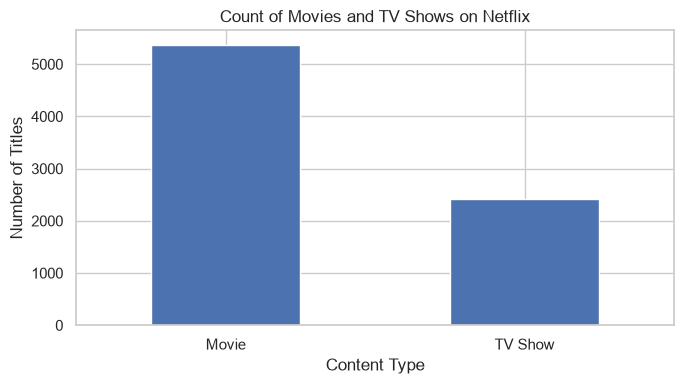

In [5]:
plt.figure(figsize=(7, 4))
type_counts.plot(kind="bar")
plt.title("Count of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
save_plot("task3_content_type_countplot")

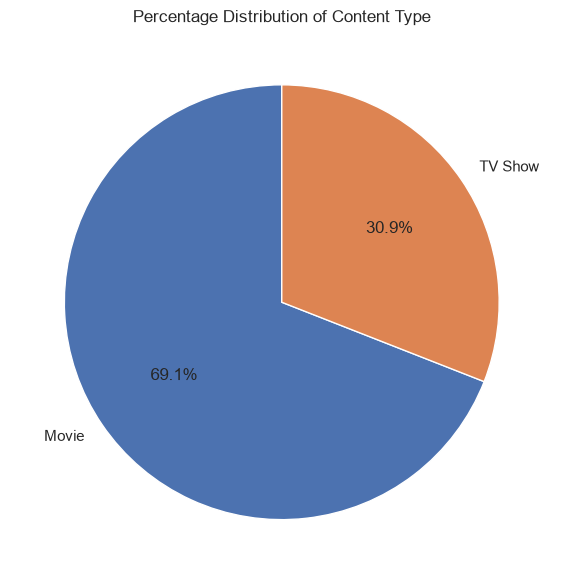

In [6]:
plt.figure(figsize=(6, 6))
type_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Percentage Distribution of Content Type")
plt.ylabel("")
save_plot("task3_content_type_piechart")

## Task 4: Country Analysis

Questions:
1. Top 10 content-producing countries.
2. Visualize country distribution.

In [7]:
country_df = netflix.assign(country=netflix["country"].str.split(", ")).explode("country").reset_index(drop=True)
top10_countries = country_df[country_df["country"] != "Unknown"]["country"].value_counts().head(10)
print("Top 10 Content-Producing Countries:")
display(top10_countries.to_frame("Number of Titles"))

Top 10 Content-Producing Countries:


,Number of Titles
country,
United States,3296
India,990
United Kingdom,722
Canada,412
France,349
Japan,287
Spain,215
South Korea,212
Germany,199


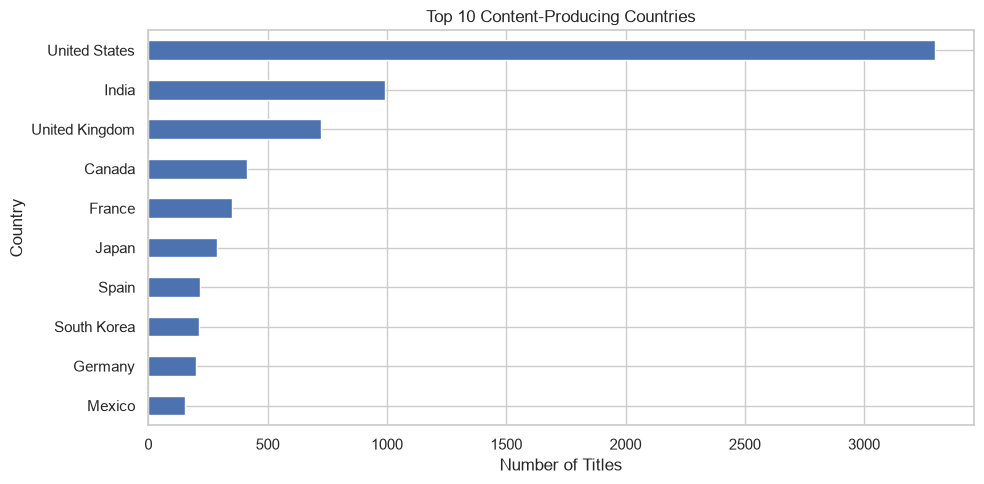

In [8]:
plt.figure(figsize=(10, 5))
top10_countries.sort_values().plot(kind="barh")
plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
save_plot("task4_top10_countries")

## Task 5: Yearly Trend Analysis

Questions:
1. Number of titles released each year.
2. Has content production increased over time?

Visualizations:
- Line Chart
- Bar Chart

In [9]:
yearly_counts = netflix.groupby("release_year").size().sort_index()
print("Number of Titles Released Each Year:")
display(yearly_counts.to_frame("Number of Titles").tail(20))
peak_year = yearly_counts.idxmax()
peak_count = yearly_counts.max()
print(f"Peak release year in this dataset: {peak_year} with {peak_count} titles")

Number of Titles Released Each Year:


,Number of Titles
release_year,
2002,45
2003,49
2004,59
2005,73
2006,85
2007,85
2008,125
2009,137
2010,173


Peak release year in this dataset: 2018 with 1121 titles


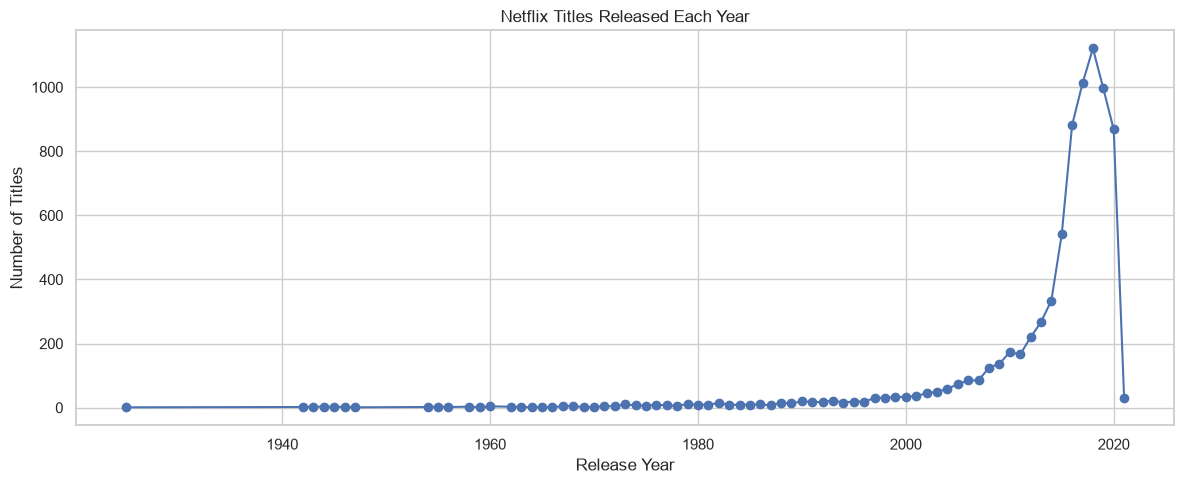

In [10]:
plt.figure(figsize=(12, 5))
yearly_counts.plot(marker="o")
plt.title("Netflix Titles Released Each Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
save_plot("task5_yearly_trend_linechart")

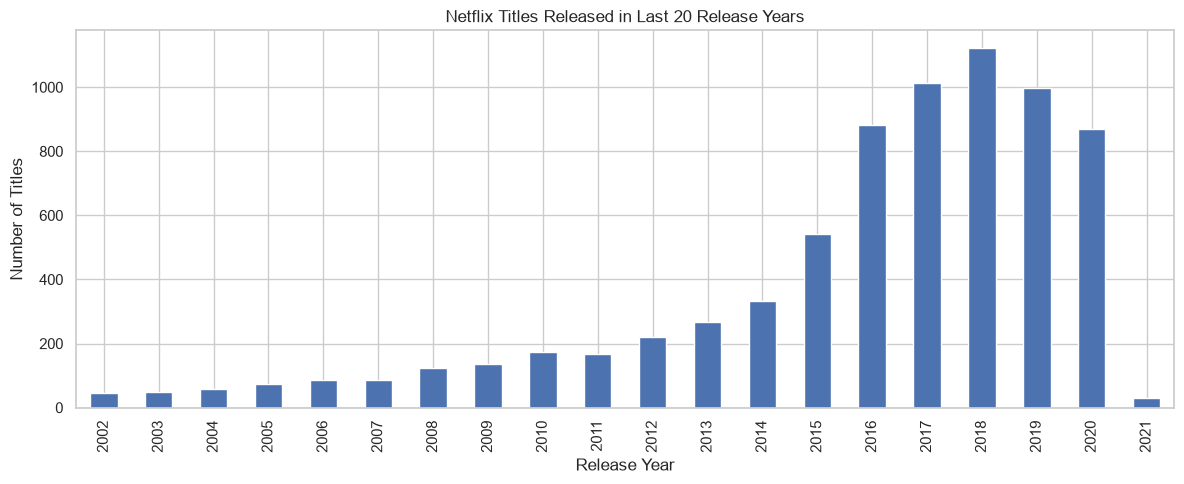

In [11]:
plt.figure(figsize=(12, 5))
yearly_counts.tail(20).plot(kind="bar")
plt.title("Netflix Titles Released in Last 20 Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
save_plot("task5_yearly_trend_barchart")

**Trend Observation:** Content production increased strongly from the 2000s to the late 2010s. In this dataset, the peak is around 2018. The 2021 count may be incomplete because the dataset does not appear to contain the full year.

## Task 6: Rating Analysis

Questions:
1. Most common maturity rating.
2. Distribution of ratings.
3. Visualize using countplots.

In [12]:
rating_counts = netflix["rating"].value_counts()
print("Most Common Rating:", rating_counts.idxmax())
display(rating_counts.to_frame("Number of Titles"))

Most Common Rating: TV-MA


,Number of Titles
rating,
TV-MA,2870
TV-14,1931
TV-PG,806
R,665
PG-13,386
TV-Y,280
TV-Y7,271
PG,247
TV-G,194


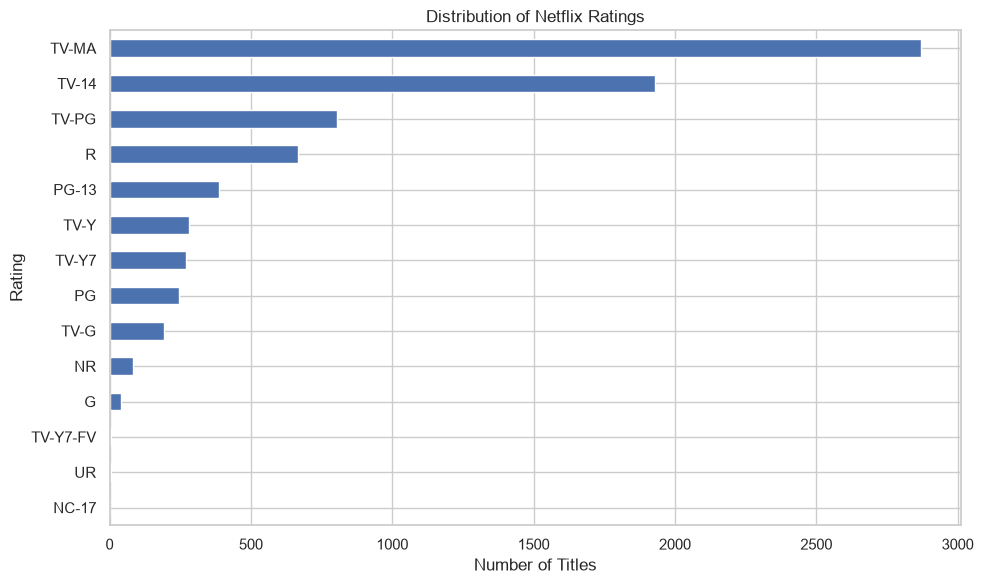

In [13]:
plt.figure(figsize=(10, 6))
rating_counts.sort_values().plot(kind="barh")
plt.title("Distribution of Netflix Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
save_plot("task6_rating_countplot")

## Task 7: Genre Analysis

Questions:
1. Top 10 genres.
2. Most popular genre category.
3. Visualize findings.

In [14]:
genre_df = netflix.assign(genres=netflix["genres"].str.split(", ")).explode("genres").reset_index(drop=True)
top10_genres = genre_df["genres"].value_counts().head(10)
print("Top 10 Genres:")
display(top10_genres.to_frame("Number of Titles"))
print("Most Popular Genre Category:", top10_genres.idxmax())

Top 10 Genres:


,Number of Titles
genres,
International Movies,2437
Dramas,2106
Comedies,1471
International TV Shows,1199
Documentaries,786
Action & Adventure,721
TV Dramas,704
Independent Movies,673
Children & Family Movies,532


Most Popular Genre Category: International Movies


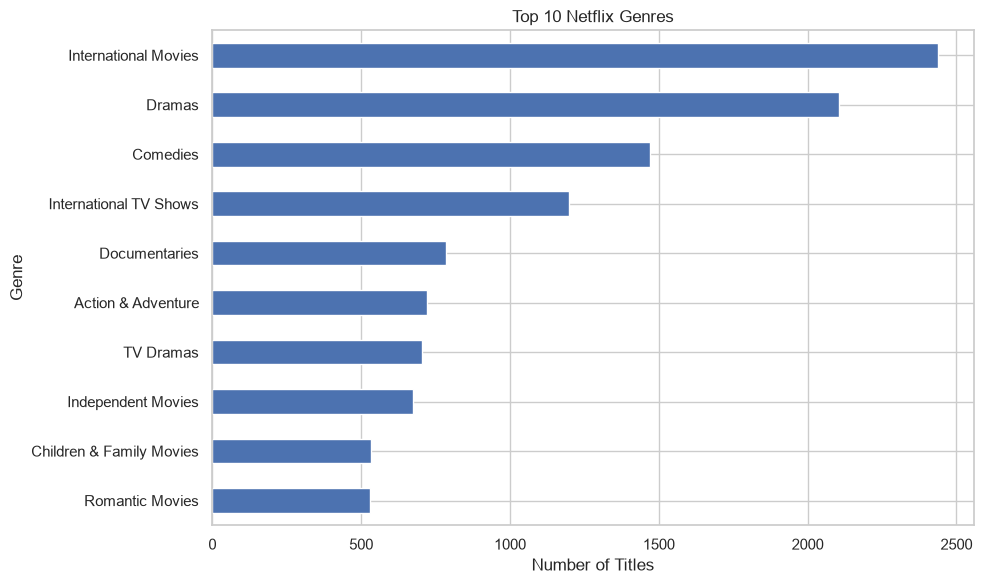

In [15]:
plt.figure(figsize=(10, 6))
top10_genres.sort_values().plot(kind="barh")
plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
save_plot("task7_top10_genres")

## Task 8: Duration Analysis

Questions:
1. Average movie duration.
2. Longest movie.
3. Shortest movie.
4. Distribution of movie duration.

Visualizations:
- Histogram
- Box Plot

In [16]:
movies = netflix[netflix["type"] == "Movie"].copy()
movies = movies.dropna(subset=["duration_num"])
average_duration = movies["duration_num"].mean()
longest_movie = movies.loc[movies["duration_num"].idxmax(), ["title", "duration_num"]]
shortest_movie = movies.loc[movies["duration_num"].idxmin(), ["title", "duration_num"]]
print(f"Average Movie Duration: {average_duration:.2f} minutes")
print("\nLongest Movie:")
display(longest_movie.to_frame().T)
print("\nShortest Movie:")
display(shortest_movie.to_frame().T)

Average Movie Duration: 99.31 minutes

Longest Movie:


,title,duration_num
7741,Black Mirror: Bandersnatch,312



Shortest Movie:


,title,duration_num
5119,Silent,3


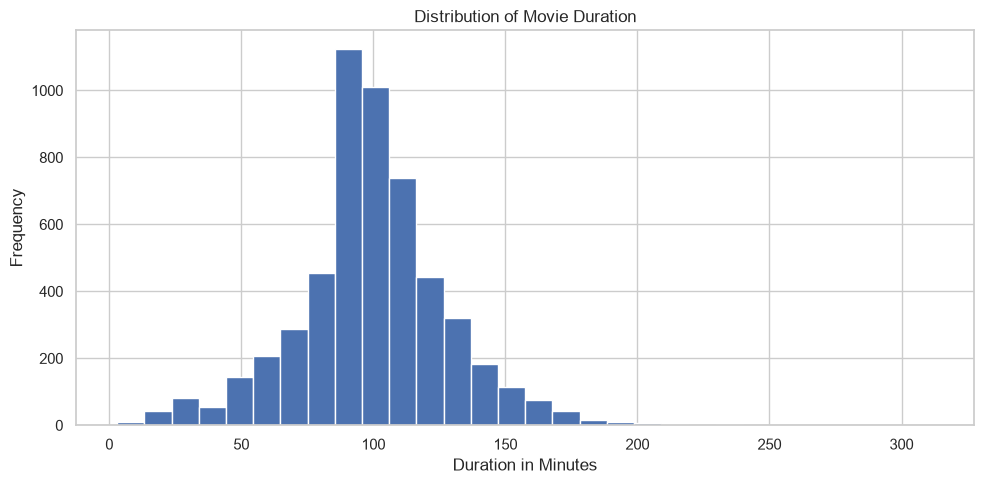

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(movies["duration_num"], bins=30)
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration in Minutes")
plt.ylabel("Frequency")
save_plot("task8_movie_duration_histogram")

C:\Users\prita\AppData\Local\Temp\ipykernel_18444\2672669195.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(movies["duration_num"], vert=False)


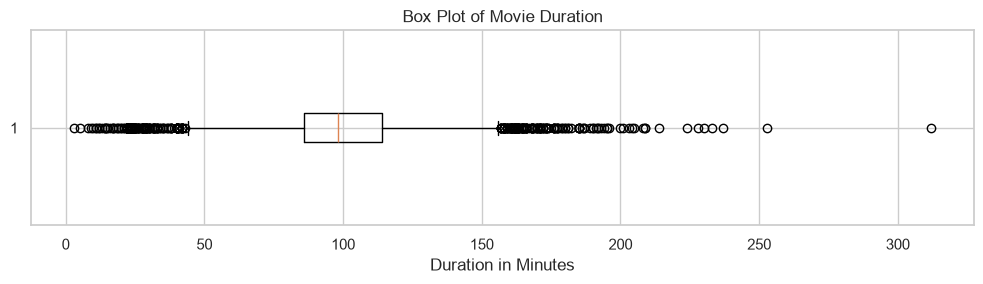

In [18]:
plt.figure(figsize=(10, 3))
plt.boxplot(movies["duration_num"], vert=False)
plt.title("Box Plot of Movie Duration")
plt.xlabel("Duration in Minutes")
save_plot("task8_movie_duration_boxplot")

## Task 9: Outlier Analysis

Using movie duration:
1. Detect outliers using IQR.
2. Detect outliers using Z-score.
3. Compare results.

In [19]:
Q1 = movies["duration_num"].quantile(0.25)
Q3 = movies["duration_num"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = movies[(movies["duration_num"] < lower_bound) | (movies["duration_num"] > upper_bound)]
movies["z_score_duration"] = (movies["duration_num"] - movies["duration_num"].mean()) / movies["duration_num"].std()
zscore_outliers = movies[movies["z_score_duration"].abs() > 3]
print("IQR Method")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of IQR Outliers:", len(iqr_outliers))
print("\nZ-score Method")
print("Number of Z-score Outliers:", len(zscore_outliers))
outlier_comparison = pd.DataFrame({
    "Method": ["IQR", "Z-score"],
    "Outlier Count": [len(iqr_outliers), len(zscore_outliers)]
})
display(outlier_comparison)
print("\nTop IQR Outliers by Duration:")
display(iqr_outliers[["title", "duration_num"]].sort_values("duration_num", ascending=False).head(10))
print("\nTop Z-score Outliers by Duration:")
display(zscore_outliers[["title", "duration_num", "z_score_duration"]].sort_values("duration_num", ascending=False).head(10))

IQR Method
Q1: 86.0
Q3: 114.0
IQR: 28.0
Lower Bound: 44.0
Upper Bound: 156.0
Number of IQR Outliers: 337

Z-score Method
Number of Z-score Outliers: 45


,Method,Outlier Count
0,IQR,337
1,Z-score,45



Top IQR Outliers by Duration:


,title,duration_num
7741,Black Mirror: Bandersnatch,312
6502,The School of Mischief,253
3880,No Longer kids,237
2995,Lock Your Girls In,233
4567,Raya and Sakina,230
4864,Sangam,228
2804,Lagaan,224
2441,Jodhaa Akbar,214
2538,Kabhi Khushi Kabhie Gham,209
6121,The Irishman,209



Top Z-score Outliers by Duration:


,title,duration_num,z_score_duration
7741,Black Mirror: Bandersnatch,312,7.454800
6502,The School of Mischief,253,5.386866
3880,No Longer kids,237,4.826070
2995,Lock Your Girls In,233,4.685871
4567,Raya and Sakina,230,4.580722
4864,Sangam,228,4.510622
2804,Lagaan,224,4.370423
2441,Jodhaa Akbar,214,4.019926
2538,Kabhi Khushi Kabhie Gham,209,3.844677
6121,The Irishman,209,3.844677


**Outlier Comparison:** IQR usually finds more duration outliers because it is stricter for skewed distributions. Z-score detects only extremely unusual durations because it uses standard deviation around the mean.

## Task 10: Feature Engineering

Create:
- Release Decade
- Content Age
- Duration Category: Short, Medium, Long

Duration category used for Movies:
- Short: up to 60 minutes
- Medium: 61 to 120 minutes
- Long: more than 120 minutes

In [20]:
CURRENT_YEAR = 2026

netflix["release_decade"] = (netflix["release_year"] // 10 * 10).astype(str) + "s"
netflix["content_age"] = CURRENT_YEAR - netflix["release_year"]
netflix["duration_category"] = np.nan
movie_duration_category = pd.cut(
    netflix.loc[netflix["type"] == "Movie", "duration_num"],
    bins=[0, 60, 120, np.inf],
    labels=["Short", "Medium", "Long"]
)
netflix["duration_category"] = pd.Series(index=netflix.index, dtype="object")
movie_idx = netflix["type"] == "Movie"
netflix.loc[movie_idx, "duration_category"] = movie_duration_category.astype(str)
print("Release Decade Distribution:")
display(netflix["release_decade"].value_counts().sort_index().to_frame("Number of Titles"))
print("\nContent Age Summary:")
display(netflix["content_age"].describe().to_frame("Content Age"))
print("\nDuration Category Distribution for Movies:")
display(netflix[netflix["type"] == "Movie"]["duration_category"].value_counts().to_frame("Number of Movies"))

Release Decade Distribution:


,Number of Titles
release_decade,
1920s,1
1940s,14
1950s,11
1960s,25
1970s,67
1980s,106
1990s,225
2000s,728
2010s,5711



Content Age Summary:


,Content Age
count,7787.000000
mean,12.067420
std,8.757395
min,5.000000
25%,8.000000
50%,9.000000
75%,13.000000
max,101.000000



Duration Category Distribution for Movies:


,Number of Movies
duration_category,
Medium,3920
Long,1011
Short,446


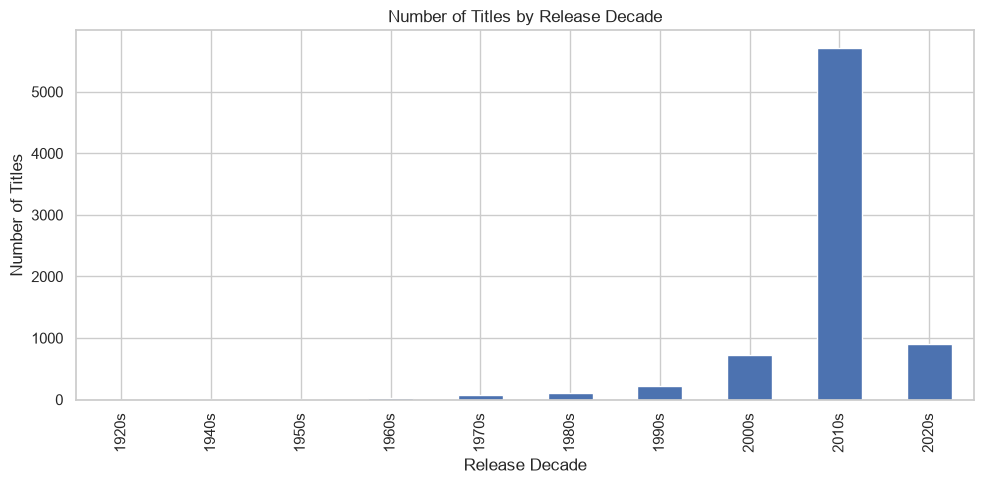

In [21]:
plt.figure(figsize=(10, 5))
netflix["release_decade"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Titles by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")
save_plot("task10_release_decade")

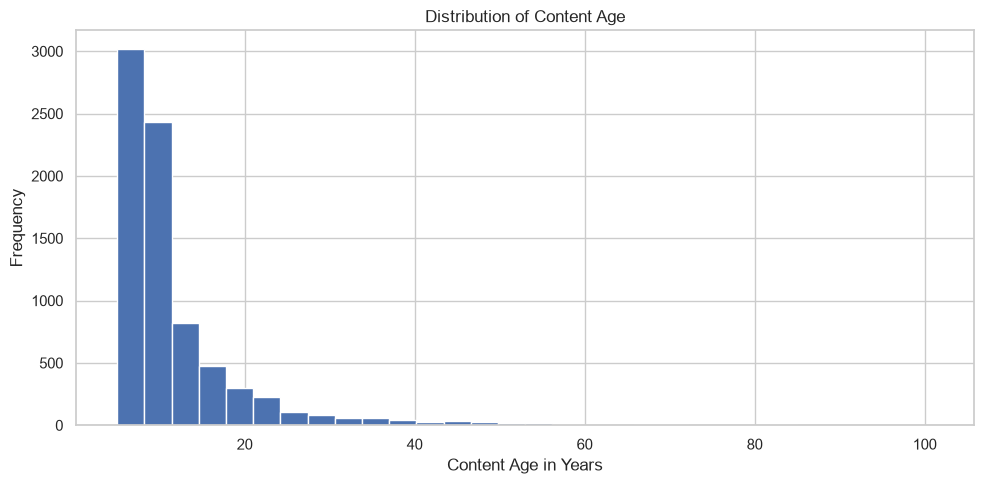

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(netflix["content_age"].dropna(), bins=30)
plt.title("Distribution of Content Age")
plt.xlabel("Content Age in Years")
plt.ylabel("Frequency")
save_plot("task10_content_age")

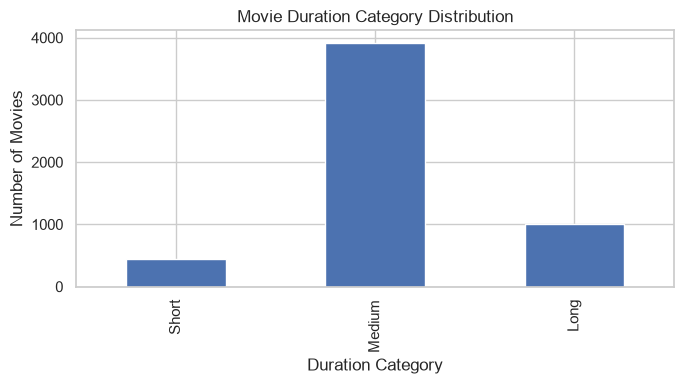

In [23]:
plt.figure(figsize=(7, 4))
duration_counts = netflix.loc[
    netflix["type"] == "Movie", "duration_category"
].value_counts().reindex(["Short", "Medium", "Long"], fill_value=0)
duration_counts.plot(kind="bar")
plt.title("Movie Duration Category Distribution")
plt.xlabel("Duration Category")
plt.ylabel("Number of Movies")
save_plot("task10_duration_category")

## Task 11: Multivariate Analysis

Investigate:
1. Country vs Content Type
2. Year vs Content Type
3. Rating vs Content Type

Use:
- Crosstab
- Heatmaps
- GroupBy

Country vs Content Type Crosstab:


type,Movie,TV Show
country,,
United States,2430,866
India,915,75
United Kingdom,466,256
Canada,286,126
France,265,84
Japan,103,184
Spain,158,57
South Korea,55,157
Germany,157,42


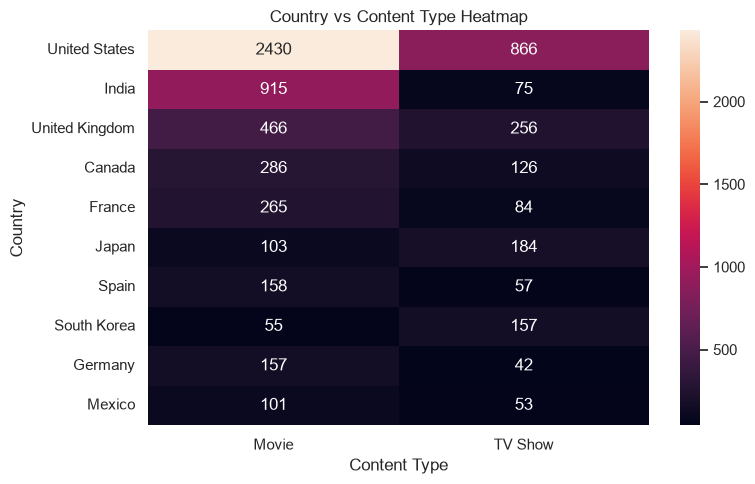

In [24]:
country_df = netflix.assign(country=netflix["country"].str.split(", ")).explode("country").reset_index(drop=True)
top_country_names = country_df[country_df["country"] != "Unknown"]["country"].value_counts().head(10).index
country_type_crosstab = pd.crosstab(country_df["country"], country_df["type"]).loc[top_country_names]
print("Country vs Content Type Crosstab:")
display(country_type_crosstab)
plt.figure(figsize=(8, 5))
sns.heatmap(country_type_crosstab, annot=True, fmt="d")
plt.title("Country vs Content Type Heatmap")
plt.xlabel("Content Type")
plt.ylabel("Country")
save_plot("task11_country_vs_type_heatmap")

Year vs Content Type Crosstab:


type,Movie,TV Show
release_year,,
2002,39,6
2003,40,9
2004,50,9
2005,61,12
2006,72,13
2007,72,13
2008,102,23
2009,103,34
2010,136,37


<Figure size 1200x500 with 0 Axes>

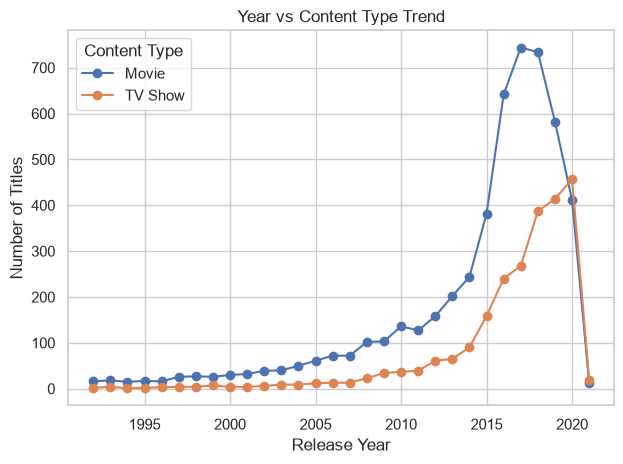

In [25]:
year_type_crosstab = pd.crosstab(netflix["release_year"], netflix["type"])
print("Year vs Content Type Crosstab:")
display(year_type_crosstab.tail(20))
plt.figure(figsize=(12, 5))
year_type_crosstab.tail(30).plot(marker="o")
plt.title("Year vs Content Type Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.tight_layout()
plt.savefig(PLOT_DIR / "task11_year_vs_type_linechart.png", dpi=150, bbox_inches="tight")
plt.show()

Rating vs Content Type Crosstab:


type,Movie,TV Show
rating,,
TV-MA,1850,1020
TV-14,1272,659
TV-PG,505,301
R,663,2
PG-13,386,0
TV-Y,117,163
TV-Y7,95,176
PG,247,0
TV-G,111,83


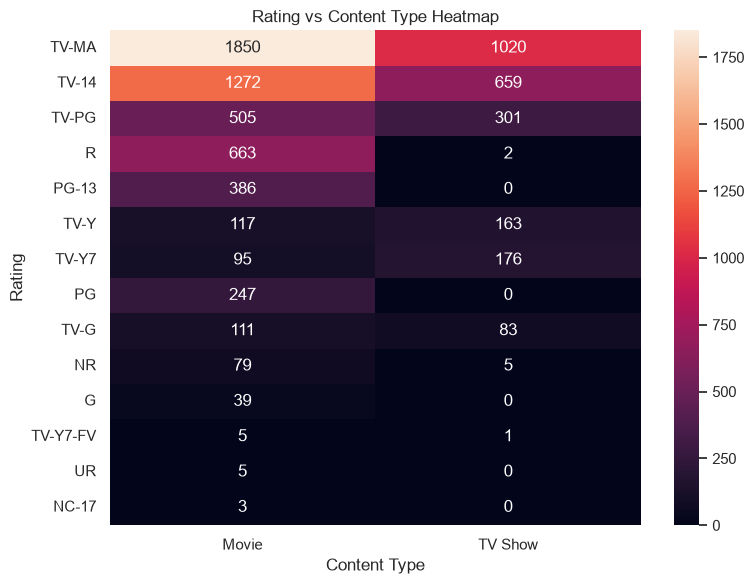

In [26]:
rating_type_crosstab = pd.crosstab(netflix["rating"], netflix["type"])
rating_order = netflix["rating"].value_counts().index
rating_type_crosstab = rating_type_crosstab.loc[rating_order]
print("Rating vs Content Type Crosstab:")
display(rating_type_crosstab)
plt.figure(figsize=(8, 6))
sns.heatmap(rating_type_crosstab, annot=True, fmt="d")
plt.title("Rating vs Content Type Heatmap")
plt.xlabel("Content Type")
plt.ylabel("Rating")
save_plot("task11_rating_vs_type_heatmap")

In [27]:
print("Average Movie Duration by Rating:")
avg_duration_by_rating = movies.groupby("rating")["duration_num"].mean().sort_values(ascending=False)
display(avg_duration_by_rating.to_frame("Average Duration"))
print("\nContent Count by Type and Rating:")
content_by_type_rating = netflix.groupby(["type", "rating"]).size().reset_index(name="count")
display(content_by_type_rating.sort_values("count", ascending=False).head(15))

Average Movie Duration by Rating:


,Average Duration
rating,
NC-17,125.000000
TV-14,110.709119
PG-13,107.772021
UR,106.800000
R,106.466063
PG,98.526316
NR,95.443038
TV-MA,95.331892
TV-PG,94.786139



Content Count by Type and Rating:


,type,rating,count
8,Movie,TV-MA,1850
6,Movie,TV-14,1272
18,TV Show,TV-MA,1020
5,Movie,R,663
16,TV Show,TV-14,659
9,Movie,TV-PG,505
4,Movie,PG-13,386
19,TV Show,TV-PG,301
3,Movie,PG,247
21,TV Show,TV-Y7,176


## Task 12: Business Insights and Strategic Recommendations

In [28]:
movies_count = type_counts.get("Movie", 0)
tv_count = type_counts.get("TV Show", 0)
movies_pct = type_percentage.get("Movie", 0)
tv_pct = type_percentage.get("TV Show", 0)
most_common_rating = rating_counts.idxmax()
most_popular_genre = top10_genres.idxmax()
most_producing_country = top10_countries.idxmax()
medium_movie_count = netflix[netflix["type"] == "Movie"]["duration_category"].value_counts().get("Medium", 0)

print("5 Business Insights")
print(f"1. Movies dominate the platform: {movies_count} Movies ({movies_pct}%) compared with {tv_count} TV Shows ({tv_pct}%).")
print(f"2. {most_producing_country} produces the highest number of Netflix titles among known countries.")
print(f"3. Content production increased strongly up to {peak_year}, where the dataset has {peak_count} titles.")
print(f"4. The most common maturity rating is {most_common_rating}, showing strong focus on mature/adult audiences.")
print(f"5. The most popular genre category is {most_popular_genre}. Medium-length movies are also very common.")
print("\n3 Strategic Recommendations")
print("1. Continue investing in international movies and dramas because these genres dominate the catalogue.")
print("2. Increase local-language content from top markets such as the United States, India, United Kingdom, Japan, and South Korea.")
print("3. Balance the catalogue by adding more family-friendly content while keeping strong TV-MA and TV-14 offerings for adult/teen audiences.")

5 Business Insights
1. Movies dominate the platform: 5377 Movies (69.05%) compared with 2410 TV Shows (30.95%).
2. United States produces the highest number of Netflix titles among known countries.
3. Content production increased strongly up to 2018, where the dataset has 1121 titles.
4. The most common maturity rating is TV-MA, showing strong focus on mature/adult audiences.
5. The most popular genre category is International Movies. Medium-length movies are also very common.

3 Strategic Recommendations
1. Continue investing in international movies and dramas because these genres dominate the catalogue.
2. Increase local-language content from top markets such as the United States, India, United Kingdom, Japan, and South Korea.
3. Balance the catalogue by adding more family-friendly content while keeping strong TV-MA and TV-14 offerings for adult/teen audiences.


### Final Written Insights

**Business Insights:**
1. Netflix catalogue is movie-heavy, so movies are the main content strength.
2. The United States, India, and the United Kingdom are the strongest content-producing markets.
3. Content production increased rapidly during the 2010s, with a peak around 2018 in this dataset.
4. Mature ratings such as TV-MA and TV-14 dominate the catalogue.
5. International Movies, Dramas, and Comedies are the most common genre categories.

**Strategic Recommendations:**
1. Invest more in international movies, dramas, and comedies because they are already highly represented and likely have broad demand.
2. Expand regional content in strong markets such as India, South Korea, Japan, and the United Kingdom.
3. Maintain mature-audience content but add more family and children-friendly titles to improve audience balance.